In [55]:
import pandas as pd
data = pd.read_excel("../data/data.xlsx")
print(data.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [56]:

data.info()



<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


1454 valeur manqaunte 

In [57]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [58]:
data.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

customer id avoir plusieur  valeur maquant 135080


In [59]:
data.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [60]:
data["InvoiceNo"].map(type).value_counts()

InvoiceNo
<class 'int'>    532618
<class 'str'>      9291
Name: count, dtype: int64

In [61]:
data[data["InvoiceNo"].astype(str).str.startswith('C')].shape[0]

9288

dropping nan customer_id row

In [62]:
data = data.dropna(subset=["CustomerID"])
print(data["CustomerID"].isna().sum())

0


In [63]:
data=data[data["UnitPrice"]>=0]
print(data["UnitPrice"].min())

0.0


recency

In [64]:
dernier_achat = data.groupby('CustomerID',as_index=False)['InvoiceDate'].max()
print(dernier_achat)

      CustomerID         InvoiceDate
0        12346.0 2011-01-18 10:17:00
1        12347.0 2011-12-07 15:52:00
2        12348.0 2011-09-25 13:13:00
3        12349.0 2011-11-21 09:51:00
4        12350.0 2011-02-02 16:01:00
...          ...                 ...
4367     18280.0 2011-03-07 09:52:00
4368     18281.0 2011-06-12 10:53:00
4369     18282.0 2011-12-02 11:43:00
4370     18283.0 2011-12-06 12:02:00
4371     18287.0 2011-10-28 09:29:00

[4372 rows x 2 columns]


FREQUENCY

In [65]:
frequency = data.groupby("CustomerID", as_index=False)["InvoiceNo"].nunique()
print(frequency)

      CustomerID  InvoiceNo
0        12346.0          2
1        12347.0          7
2        12348.0          4
3        12349.0          1
4        12350.0          1
...          ...        ...
4367     18280.0          1
4368     18281.0          1
4369     18282.0          3
4370     18283.0         16
4371     18287.0          3

[4372 rows x 2 columns]


In [66]:
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
print(data["TotalPrice"])

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalPrice, Length: 406829, dtype: float64


In [67]:
monetary = data.groupby("CustomerID", as_index=False)["TotalPrice"].sum()
print(monetary)

      CustomerID  TotalPrice
0        12346.0        0.00
1        12347.0     4310.00
2        12348.0     1797.24
3        12349.0     1757.55
4        12350.0      334.40
...          ...         ...
4367     18280.0      180.60
4368     18281.0       80.82
4369     18282.0      176.60
4370     18283.0     2094.88
4371     18287.0     1837.28

[4372 rows x 2 columns]


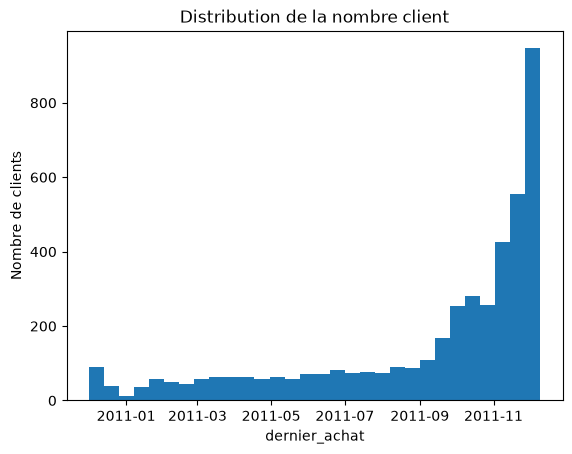

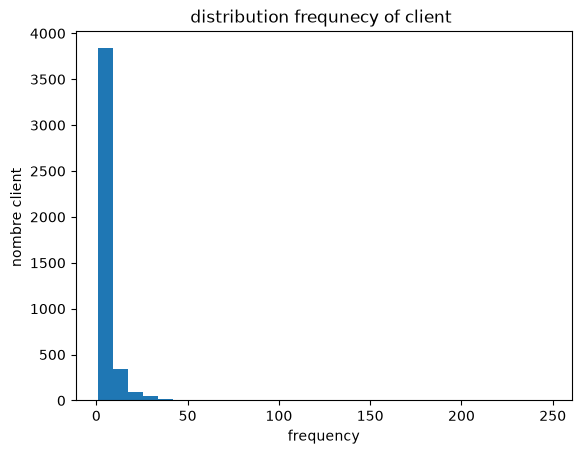

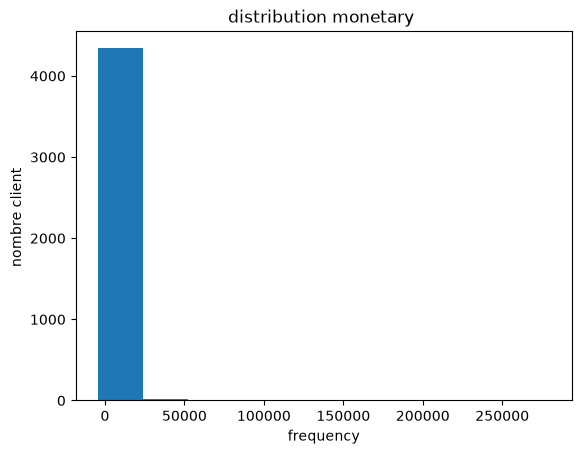

In [68]:
import matplotlib.pyplot as plt

plt.hist(dernier_achat["InvoiceDate"], bins=30)
plt.xlabel("dernier_achat")
plt.ylabel("Nombre de clients")
plt.title("Distribution de la nombre client")
plt.show()

plt.hist(frequency["InvoiceNo"],bins=30)
plt.xlabel("frequency")
plt.ylabel("nombre client ")
plt.title("distribution frequnecy of client ")
plt.show()

plt.hist(monetary["TotalPrice"],bins=10)
plt.xlabel("frequency")
plt.ylabel("nombre client ")
plt.title("distribution monetary ")
plt.show()

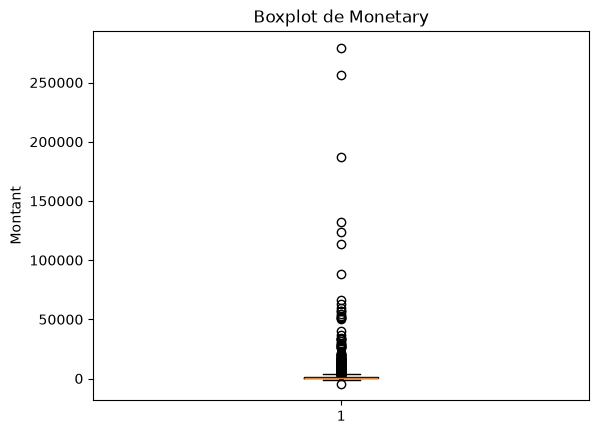

In [69]:
plt.boxplot(monetary["TotalPrice"])
plt.title("Boxplot de Monetary")
plt.ylabel("Montant")
plt.show()

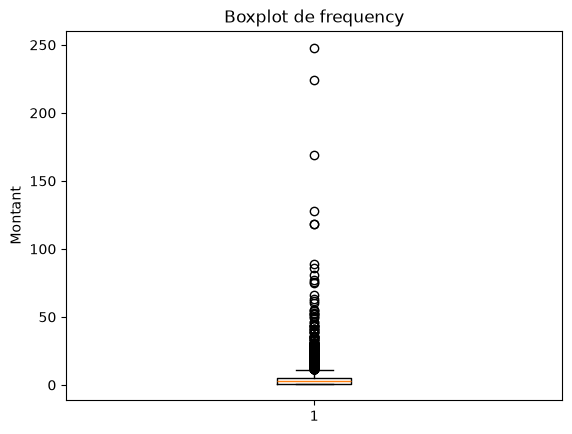

In [70]:
plt.boxplot(frequency["InvoiceNo"])
plt.title("Boxplot de frequency")
plt.ylabel("Montant")
plt.show()

In [71]:
rfm = dernier_achat.merge(frequency, on="CustomerID")
rfm = rfm.merge(monetary, on="CustomerID")

print(rfm)


      CustomerID         InvoiceDate  InvoiceNo  TotalPrice
0        12346.0 2011-01-18 10:17:00          2        0.00
1        12347.0 2011-12-07 15:52:00          7     4310.00
2        12348.0 2011-09-25 13:13:00          4     1797.24
3        12349.0 2011-11-21 09:51:00          1     1757.55
4        12350.0 2011-02-02 16:01:00          1      334.40
...          ...                 ...        ...         ...
4367     18280.0 2011-03-07 09:52:00          1      180.60
4368     18281.0 2011-06-12 10:53:00          1       80.82
4369     18282.0 2011-12-02 11:43:00          3      176.60
4370     18283.0 2011-12-06 12:02:00         16     2094.88
4371     18287.0 2011-10-28 09:29:00          3     1837.28

[4372 rows x 4 columns]


In [72]:
date_reference = data["InvoiceDate"].max()

rfm["Recency"] = (
    date_reference - rfm["InvoiceDate"]
).dt.days

rfm = rfm.drop(columns=["InvoiceDate"])

rfm = rfm.rename(columns={
    "InvoiceNo": "Frequency",
    "TotalPrice": "Monetary"
})

print(rfm.head())

   CustomerID  Frequency  Monetary  Recency
0     12346.0          2      0.00      325
1     12347.0          7   4310.00        1
2     12348.0          4   1797.24       74
3     12349.0          1   1757.55       18
4     12350.0          1    334.40      309


In [73]:
print(rfm.head())

   CustomerID  Frequency  Monetary  Recency
0     12346.0          2      0.00      325
1     12347.0          7   4310.00        1
2     12348.0          4   1797.24       74
3     12349.0          1   1757.55       18
4     12350.0          1    334.40      309


In [74]:
print(rfm[["Recency", "Frequency", "Monetary"]].dtypes)

Recency        int64
Frequency      int64
Monetary     float64
dtype: object


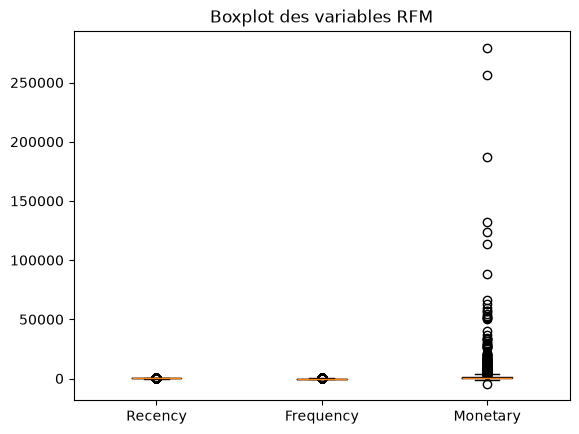

In [75]:
X = rfm[["Recency", "Frequency", "Monetary"]].dropna()
plt.boxplot(X)
plt.xticks([1, 2, 3], ["Recency", "Frequency", "Monetary"])
plt.title("Boxplot des variables RFM")
plt.show()

 Vérification de la distribution et de l'asymétrie (Skewness)


In [76]:
import numpy as np
import matplotlib.pyplot as plt

X = rfm[["Recency", "Frequency", "Monetary"]].copy()
print(X.head())

print(X.skew())


   Recency  Frequency  Monetary
0      325          2      0.00
1        1          7   4310.00
2       74          4   1797.24
3       18          1   1757.55
4      309          1    334.40
Recency       1.249665
Frequency    11.412274
Monetary     21.705287
dtype: float64


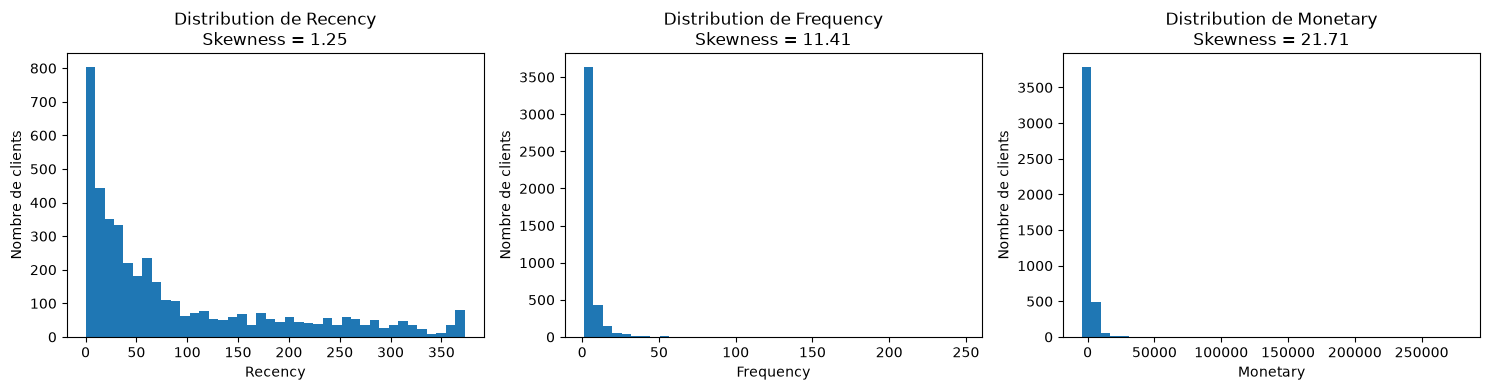

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    axes[i].hist(X[col], bins=40)
    axes[i].set_title(
        f"Distribution de {col}\nSkewness = {X[col].skew():.2f}"
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

In [78]:
X_log = np.log1p(X)
X_log=X_log.dropna()
print(X_log)

       Recency  Frequency  Monetary
0     5.786897   1.098612  0.000000
1     0.693147   2.079442  8.368925
2     4.317488   1.609438  7.494564
3     2.944439   0.693147  7.472245
4     5.736572   0.693147  5.815324
...        ...        ...       ...
4367  5.627621   0.693147  5.201806
4368  5.198497   0.693147  4.404522
4369  2.079442   1.386294  5.179534
4370  1.386294   2.833213  7.647729
4371  3.761200   1.386294  7.516586

[4331 rows x 3 columns]


C:\Users\Youcode\AppData\Roaming\Python\Python314\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


LOG AND TRAINING FITING 

In [79]:
from sklearn.preprocessing  import StandardScaler

scaler =StandardScaler()
x_fited=scaler.fit_transform(X_log)
X_clean = X.loc[X_log.index].copy()
print(x_fited)


[[ 1.41798058 -0.47445856 -5.05301076]
 [-2.070743    0.85623301  1.40176449]
 [ 0.41157811  0.21857884  0.72738794]
 ...
 [-1.12126616 -0.08416014 -1.0581457 ]
 [-1.59600458  1.87887562  0.84552095]
 [ 0.03057493 -0.08416014  0.744373  ]]


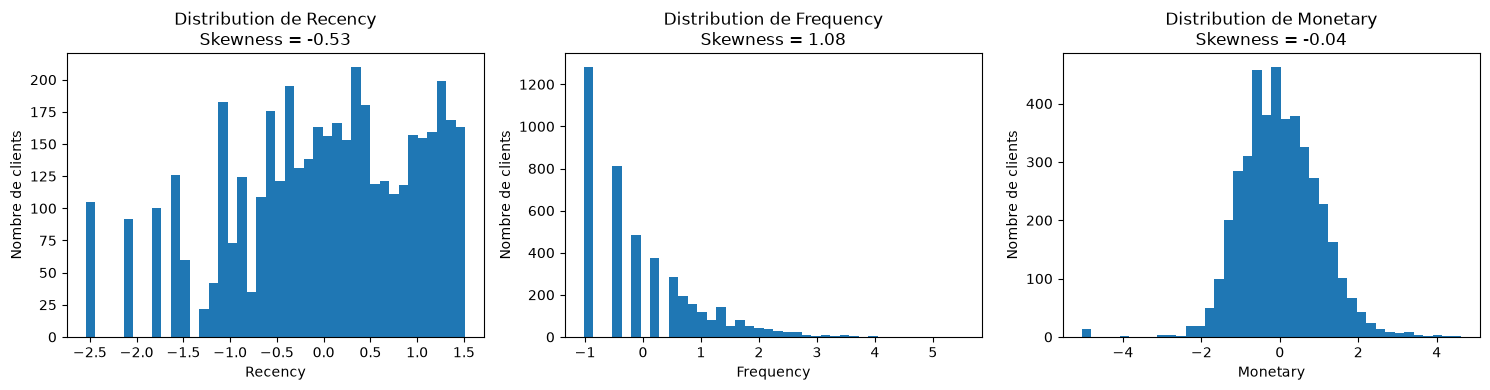

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

columns = ["Recency", "Frequency", "Monetary"]

for i, col in enumerate(columns):
    axes[i].hist(x_fited[:, i], bins=40)
    axes[i].set_title(
        f"Distribution de {col}\nSkewness = {pd.Series(x_fited[:, i]).skew():.2f}"
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()


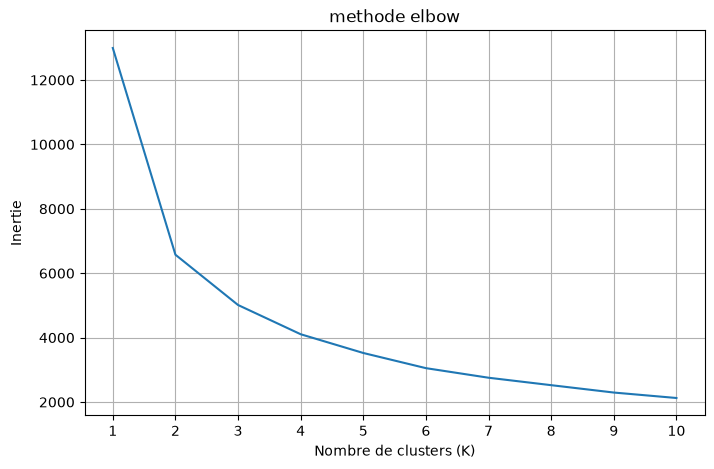

In [81]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_fited)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias)

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.title("methode elbow")
plt.xticks(K)
plt.grid(True)
plt.show()

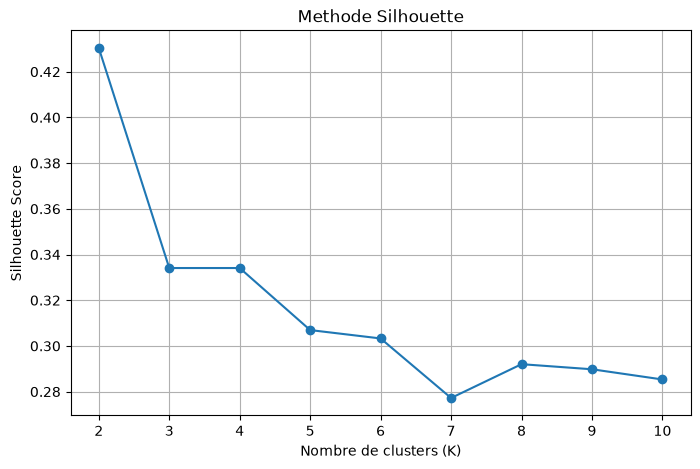

In [82]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_fited)

    score = silhouette_score(x_fited, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker="o")

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Methode Silhouette")
plt.xticks(K)
plt.grid(True)
plt.show()

In [83]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

X_clean["Cluster"] = kmeans.fit_predict(x_fited)

print(X_clean.head())

   Recency  Frequency  Monetary  Cluster
0      325          2      0.00        0
1        1          7   4310.00        1
2       74          4   1797.24        2
3       18          1   1757.55        2
4      309          1    334.40        0


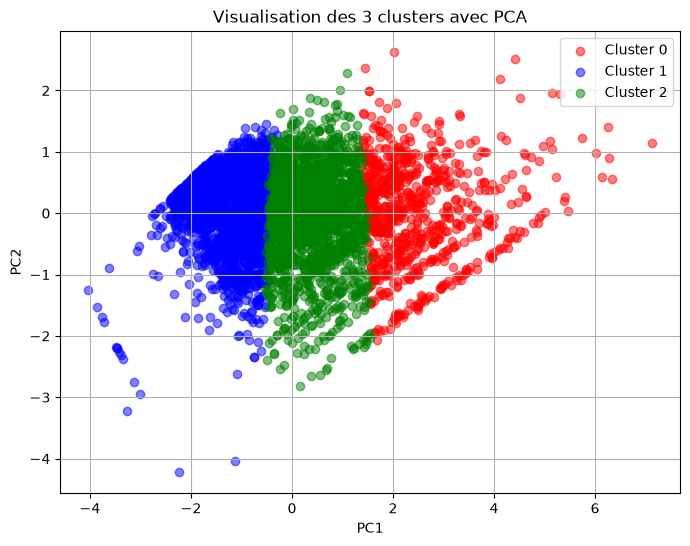

In [84]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as mtb


pca = PCA(n_components=2)
rfmPCA = pca.fit_transform(x_fited)

kmeans = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=0
)

labels_fit = kmeans.fit_predict(x_fited)

# Ajouter les labels_fit au DataFrame
X_clean["Cluster"] = labels_fit

# Visualisation des clusters
colors = ["red", "blue", "green"]

mtb.figure(figsize=(8, 6))

for i in range(3):
    mtb.scatter(
        rfmPCA[labels_fit == i, 0],
        rfmPCA[labels_fit == i, 1],
        color=colors[i],
        label=f"Cluster {i}",
        alpha=0.5
    )

mtb.xlabel("PC1")
mtb.ylabel("PC2")
mtb.title("Visualisation des 3 clusters avec PCA")
mtb.legend()
mtb.grid()
mtb.show()

PARTIE RANDOM FORESTE 

In [85]:
x = X_clean[["Recency", "Frequency", "Monetary"]]

y =X_clean["Cluster"]
print(x.head())
print("swdv")
print(y)

   Recency  Frequency  Monetary
0      325          2      0.00
1        1          7   4310.00
2       74          4   1797.24
3       18          1   1757.55
4      309          1    334.40
swdv
0       1
1       0
2       2
3       2
4       1
       ..
4367    1
4368    1
4369    2
4370    0
4371    2
Name: Cluster, Length: 4331, dtype: int32


In [86]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test =train_test_split(

    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [87]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(
    n_estimators=100,
 random_state=42
)
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [88]:
y_pred = model.predict(X_test)
print(y_pred)

[1 2 1 1 1 0 0 1 1 2 1 2 0 1 0 1 1 1 1 2 1 2 1 1 1 2 1 0 1 2 2 2 2 2 0 0 2
 1 1 1 1 1 1 2 1 1 1 1 2 1 1 2 1 2 0 0 2 1 2 1 1 1 0 2 0 1 2 2 2 2 1 1 2 0
 1 2 0 2 0 2 1 1 2 0 1 2 1 1 1 0 2 1 2 0 1 2 1 1 2 0 1 2 2 2 1 2 1 2 2 1 1
 0 2 2 0 2 0 0 2 1 0 1 1 0 1 1 1 2 2 1 2 2 1 1 1 2 1 1 2 1 1 0 2 2 1 2 0 2
 1 1 1 0 2 2 1 1 2 0 1 0 2 2 2 0 1 0 2 1 2 1 2 1 1 0 1 2 1 1 2 1 0 2 0 2 2
 2 1 2 2 1 0 1 0 2 0 2 1 2 1 2 2 1 1 1 1 1 2 1 2 2 0 2 1 1 0 1 1 2 1 0 1 1
 1 0 1 1 1 0 1 0 2 1 1 2 1 2 1 1 0 0 2 1 1 1 2 1 1 1 0 2 2 1 1 0 2 2 0 1 2
 1 1 1 1 2 2 2 2 1 2 1 1 2 1 1 2 2 1 2 2 2 2 2 2 0 1 1 1 1 2 1 1 1 1 1 0 0
 0 1 0 1 1 2 2 2 0 2 0 2 0 2 1 2 1 1 2 2 1 2 2 1 1 1 1 1 1 1 1 1 1 2 1 1 1
 1 2 0 0 1 2 2 2 2 2 1 2 0 0 0 1 2 0 1 1 1 2 2 2 2 1 2 2 2 1 0 1 2 2 1 1 2
 2 1 1 1 1 1 2 2 1 2 1 2 2 2 2 0 1 1 1 2 0 2 2 2 0 2 1 2 2 1 2 2 0 1 2 1 1
 2 1 1 2 1 1 1 1 1 1 1 2 1 1 2 1 1 2 0 1 1 2 1 2 2 1 1 2 1 2 1 2 1 2 1 1 0
 2 1 1 1 2 2 2 1 1 2 0 2 0 2 1 1 0 0 2 2 1 1 2 2 2 1 1 1 1 2 1 2 1 0 0 1 1
 0 2 1 1 2 1 2 2 0 2 1 1 

In [89]:
print("Classes reelles :", y_test.values[:10])
print("Predictions     :", y_pred[:10])

Classes reelles : [1 2 1 1 1 0 2 1 1 2]
Predictions     : [1 2 1 1 1 0 0 1 1 2]


In [102]:
from sklearn.preprocessing import  StandardScaler
scaler=StandardScaler()
x_scaled = scaler.fit_transform(X_log)


EVALUATION DE MODEL 

In [90]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)


print("Accuracy :", accuracy)
print(f"Accuracy : {accuracy * 100:.2f}%")
print(classification_report(y_test,y_pred))

Accuracy : 0.9746251441753172
Accuracy : 97.46%
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       148
           1       0.98      0.99      0.98       387
           2       0.97      0.96      0.97       332

    accuracy                           0.97       867
   macro avg       0.97      0.97      0.97       867
weighted avg       0.97      0.97      0.97       867



In [91]:


nouveau_client = pd.DataFrame({
    "Recency": [30],
    "Frequency": [8],
    "Monetary": [1500]
})

print(nouveau_client)

   Recency  Frequency  Monetary
0       30          8      1500


In [92]:
y_pred=model.predict(nouveau_client)[0]
print(y_pred)

2


In [93]:
print(model.classes_)

[0 1 2]


In [94]:
cc=X_clean.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cc)


            Recency  Frequency     Monetary
Cluster                                    
0         12.750678  16.586721  7486.934404
1        157.034091   1.513946   345.754515
2         44.418829   4.197345  1278.549561


In [95]:
noms_segments = {
    0: "Clients VIP",
    1: "Clients a risque",
    2: "Clients reguliers"
}

In [96]:
nom_segment = noms_segments[y_pred]

print("Cluster :", y_pred)
print("Segment :", nom_segment)

Cluster : 2
Segment : Clients reguliers


In [103]:
import joblib

joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']

In [ ]:
scaler_test = joblib.load("scaler.joblib")

print("Scaler chargé avec succes")

Scaler chargé avec succès


In [104]:
import joblib

joblib.dump(model, "random_forest_model.joblib")

['random_forest_model.joblib']

In [105]:
model_loaded=joblib.load("random_forest_model.joblib")